# 4 · Your First Backtest

*Common Core*

A backtest answers one question: *if I had followed this rule in the past, what would have happened?* This notebook builds one from scratch for a simple trend-following rule. Every later strategy uses the same skeleton.

## 1. Motivation

A popular rule of thumb says: "Own the stock market when it is above its 200-day average price. Otherwise, sit in cash." Supporters claim it avoids the worst crashes. Critics say it just makes you miss the recoveries. We can settle this with data instead of opinions. And we will see how a single line of code can make a useless rule look brilliant.

## 2. Intuition

Every backtest has the same four steps:

1. **Signal.** Using only information available *today*, decide what you want to hold.
2. **Position.** Turn the signal into holdings, e.g. 100% in SPY or 100% in cash.
3. **Returns.** Your return *tomorrow* is your position *today* times the asset's return *tomorrow*.
4. **Evaluate.** Compare against a simple alternative (here, just buying and holding SPY) using the measures from notebook 2.

Step 3 is where most mistakes happen. If today's position uses today's closing price, you can only trade at that close at the earliest, so you earn *tomorrow's* return, not today's. Getting this timing wrong is called **look-ahead bias**: the backtest quietly uses information from the future.

## 3. The math

Let $P_t$ be SPY's price and define the 200-day **simple moving average**:
$$
\text{SMA}_t = \frac{1}{200}\sum_{k=0}^{199} P_{t-k}.
$$

**Signal**, known at the close of day $t$:
$$
s_t = \begin{cases} 1 & \text{if } P_t > \text{SMA}_t \quad(\text{hold SPY})\\ 0 & \text{otherwise} \quad(\text{hold T-bills}) \end{cases}
$$

**Strategy return** on day $t+1$. The position chosen at the close of day $t$ earns the next day's returns:
$$
R^{\text{strat}}_{t+1} = s_t \, R^{\text{SPY}}_{t+1} + (1 - s_t)\, r_{f,t+1}.
$$

In pandas, using $s_t$ with day $t+1$'s return is done with `signal.shift(1)`. Forgetting that shift means using $s_{t+1}$, which depends on $P_{t+1}$, to trade *during* day $t+1$. That is the look-ahead bug.

## 4. Code it

### 4.1 Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

prices = pd.read_csv("../data/prices.csv", index_col="date", parse_dates=True)

COLORS = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
plt.rcParams.update({
    "figure.figsize": (9, 4.5), "figure.dpi": 100, "axes.prop_cycle": plt.cycler(color=COLORS),
    "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True,
    "grid.alpha": 0.3, "lines.linewidth": 1.5, "font.size": 11,
})

spy = prices["SPY"]
spy_ret = spy.pct_change()
rf = (prices["^IRX"].ffill() / 100 / 252).shift(1)   # daily T-bill return (notebook 2)

### 4.2 Steps 1–2: signal and position

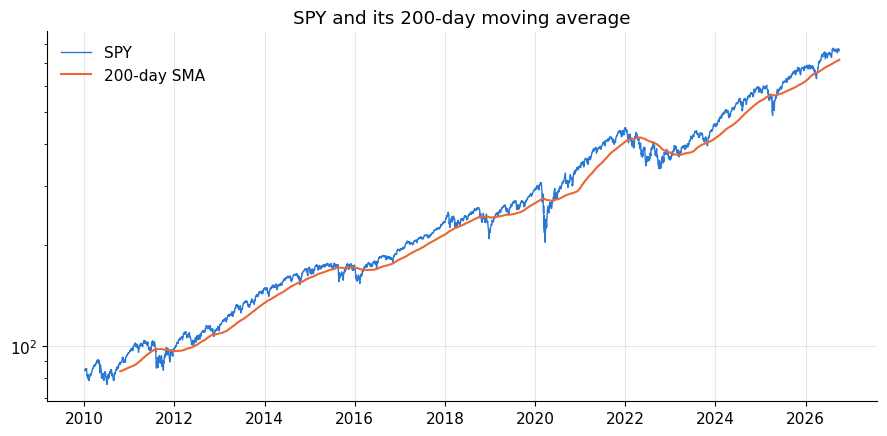

Fraction of days invested in SPY: 85%
Number of switches in or out: 78


In [2]:
sma = spy.rolling(200).mean()            # SMA_t, the 200-day average price
signal = (spy > sma).astype(int)         # s_t = 1 if P_t > SMA_t, else 0
signal[sma.isna()] = np.nan              # no signal until we have 200 days of history

fig, ax = plt.subplots()
ax.plot(spy.index, spy, label="SPY", linewidth=1)
ax.plot(sma.index, sma, label="200-day SMA", color=COLORS[1])
ax.set_yscale("log")
ax.set_title("SPY and its 200-day moving average")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

print(f"Fraction of days invested in SPY: {signal.mean():.0%}")
print(f"Number of switches in or out: {int(signal.diff().abs().sum())}")

### 4.3 Step 3: strategy returns, with the correct timing

In [3]:
position = signal.shift(1)   # s_t decided at today's close is held over tomorrow

# R_strat(t+1) = s_t * R_SPY(t+1) + (1 - s_t) * r_f(t+1)
strat = position * spy_ret + (1 - position) * rf

# Line up both series on the days where the strategy is live
df = pd.DataFrame({"Trend rule": strat, "Buy & hold SPY": spy_ret}).dropna()

### 4.4 Step 4: evaluate

In [4]:
def performance(returns, rf):
    """CAGR, volatility, Sharpe and max drawdown (formulas from notebook 2)."""
    rf = rf.reindex(returns.index)
    excess = returns.sub(rf, axis=0)
    value = (1 + returns).cumprod()
    years = len(returns) / 252
    out = pd.DataFrame({
        "CAGR": value.iloc[-1] ** (1 / years) - 1,
        "Volatility": returns.std() * np.sqrt(252),
        "Sharpe": np.sqrt(252) * excess.mean() / excess.std(),
        "Max drawdown": (value / value.cummax() - 1).min(),
    })
    fmt = {"CAGR": "{:.1%}", "Volatility": "{:.1%}", "Sharpe": "{:.2f}", "Max drawdown": "{:.1%}"}
    return out.apply(lambda col: col.map(fmt[col.name].format))

performance(df, rf)

,CAGR,Volatility,Sharpe,Max drawdown
Trend rule,11.0%,11.7%,0.82,-18.1%
Buy & hold SPY,14.4%,16.9%,0.79,-33.7%


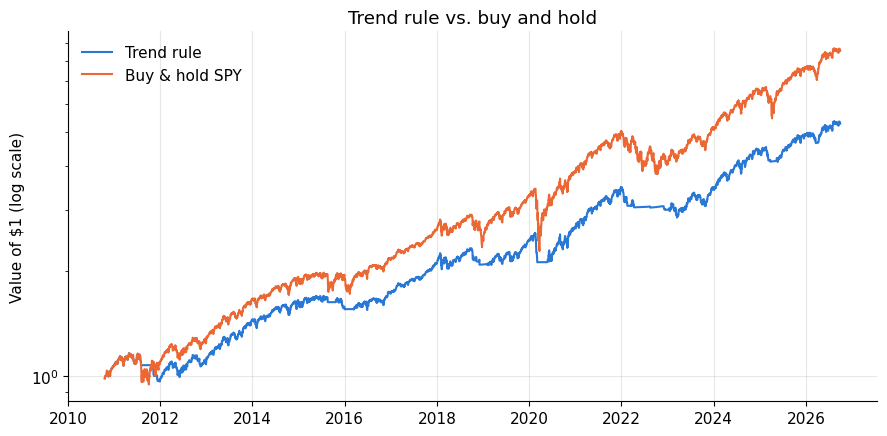

In [5]:
growth = (1 + df).cumprod()

fig, ax = plt.subplots()
for col in growth:
    ax.plot(growth.index, growth[col], label=col)
ax.set_yscale("log")
ax.set_ylabel("Value of $1 (log scale)")
ax.set_title("Trend rule vs. buy and hold")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

The honest result is mixed, which is typical of real research:

- **The trend rule earned less**: about 11% a year against 14.4% for buy-and-hold. It sat in T-bills during several sharp drops that quickly reversed. It sold near the bottom and bought back higher, which is what critics of the rule warn about.
- **It was much less risky.** Volatility fell from about 17% to 12%, and the max drawdown was cut roughly in half (−18% vs −34%).
- **The Sharpe ratios are almost the same** (0.82 vs 0.79). Per unit of risk, the rule did not add much. It mainly traded return for a smoother ride.

Whether that trade is worth it depends on the investor. That is a portfolio decision, not a statistical one.

### 4.5 The one-line bug

Now we remove `.shift(1)`. The strategy then uses the signal computed from day $t+1$'s close to earn day $t+1$'s return. A rule that sees today's close before deciding whether to hold today will naturally sit out many of the down days.

In [6]:
cheating = signal * spy_ret + (1 - signal) * rf   # BUG: no shift -> uses the future
df_bug = pd.DataFrame({"Trend rule (correct)": strat,
                       "Trend rule (look-ahead bug)": cheating,
                       "Buy & hold SPY": spy_ret}).dropna()
performance(df_bug, rf)

,CAGR,Volatility,Sharpe,Max drawdown
Trend rule (correct),11.0%,11.7%,0.82,-18.1%
Trend rule (look-ahead bug),20.9%,11.7%,1.56,-10.1%
Buy & hold SPY,14.4%,16.9%,0.79,-33.7%


One missing `.shift(1)` almost **doubles the annual return** (11% → 21%), doubles the Sharpe ratio and cuts the drawdown in half again. Nothing about the strategy changed. The buggy version simply knows each day's closing price before deciding whether to hold that day. Results like the middle row are a warning sign, not a discovery. Notebook 6 covers this and other biases in more depth.

## 5. Takeaways and where it breaks

- **Every backtest is signal → position → returns → evaluation.** Later notebooks only change the signal.
- **Shift your positions.** A signal computed with day $t$'s data can only earn returns from day $t+1$ onwards. When a backtest looks too good, check the timing first.
- **Always compare against a benchmark.** "The strategy made money" means little if buy-and-hold made more.
- **This backtest is still optimistic.** It ignores trading costs (notebook 7), assumes you can trade at exactly the closing price that generated the signal, and uses one fixed rule chosen *after* seeing decades of market history (notebook 6).
- **One asset, one period.** The trend rule's main benefit, avoiding long bear markets, depends on a few big episodes. With so few of them, it is hard to tell skill from luck.

**What you could build:** a reusable `backtest(signal, returns)` function that applies the shift for you, so nobody on the team can make the timing mistake by accident.